# R6 — Estudio de ablation por familias de variables

## Necesidad

sin un ablation no se puede sostener que las señales comportamentales aporten algo
propio, por eso la importancia del estudio de las familias de variables.


-  **`call_overlap_duration_s` cambia de familia.** Estaba clasificada en
   `transaction` y es una variable de contexto de sesión. Se movió a `context`,
   lo que hace que esta ablation no sea comparable número a número con la
   anterior: la familia `transaction` pierde una variable y `context` gana una.

## Diseño

Seis configuraciones, todas evaluadas **sobre validation** (el test quedó
cerrado en R5):

1. `context_transaction` — solo contexto y transacción (11 features)
2. `behavioral` — solo biometría comportamental (33 features)
3. `behavioral_context`
4. `behavioral_transaction`
5. `all` — todas (44)
6. `all_sin_phone_call` — todas menos `phone_call_active` y `call_overlap_duration_s`

In [ ]:

import sys, os

AQUI = os.getcwd()                    # los notebooks y vishing_common.py conviven
if AQUI not in sys.path:
    sys.path.insert(0, AQUI)

import numpy as np
import pandas as pd
import vishing_common as vc

vc.set_all_seeds()                    # random, numpy y torch (+ cuDNN determinista)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

print("dataset:", vc.RAW_FILENAME, "(esquema", vc.DATASET_VERSION + ")")
print("bucket :", vc.BUCKET, "| prefijo:", vc.PREFIX)
print("seed   :", vc.SEED, "| split:", vc.SPLIT_MODE, "| política:", vc.FEATURE_POLICY)
print("xgboost se ejecutará en:", vc.xgb_device())
vc.check_versions()

dataset: biocatch_sinthetic_data_v3.csv (esquema v3)
bucket : poc-vishing | prefijo: v2
seed   : 42 | split: grouped | política: audited
xgboost se ejecutará en: cuda
  versiones OK: numpy 2.0.2, pandas 2.2.3, scipy 1.14.1, sklearn 1.5.2, imblearn 0.12.4, xgboost 2.1.4


,paquete,instalada,esperado,ok
0,numpy,2.0.2,">=1.26,<2.1",True
1,pandas,2.2.3,">=2.1,<2.3",True
2,scipy,1.14.1,">=1.11,<1.15",True
3,sklearn,1.5.2,">=1.4,<1.6",True
4,imblearn,0.12.4,">=0.12,<0.13",True
5,xgboost,2.1.4,">=2.0,<2.2",True


In [2]:
from xgboost import XGBClassifier

cfg = vc.read_json(vc.P.feature_contract)
contract = cfg["contratos"][cfg["activo"]]
fam = contract["families"]

ganador = vc.read_json(vc.P.val_leaderboard.replace(
    "validation_leaderboard.csv", "ganador.json"))["ganador"]
print("se replica la configuración ganadora de R4:", ganador["variante"],
      "/", ganador["data_type"], "/", ganador["technique"], "/", ganador["ratio"])

train_bal = vc.read_parquet(vc.P.balanced(ganador["data_type"], ganador["technique"],
                                          ganador["ratio"]))
val = vc.read_parquet(vc.P.val)
yv = val[vc.TARGET].values
yt = train_bal[vc.TARGET].values

se replica la configuración ganadora de R4: xgb_shallow / original / none / 0


In [3]:
PHONE = ["phone_call_active", "call_overlap_duration_s"]

CONFIGS = {
    "context_transaction":    fam["context"] + fam["transaction"],
    "behavioral":             fam["behavioral"],
    "behavioral_context":     fam["behavioral"] + fam["context"],
    "behavioral_transaction": fam["behavioral"] + fam["transaction"],
    "all":                    contract["features"],
    "all_sin_phone_call":     [f for f in contract["features"] if f not in PHONE],
}
for k, v in CONFIGS.items():
    presentes = [f for f in v if f in contract["features"]]
    CONFIGS[k] = presentes
    print("%-24s %2d features" % (k, len(presentes)))

context_transaction      11 features
behavioral               33 features
behavioral_context       40 features
behavioral_transaction   37 features
all                      44 features
all_sin_phone_call       42 features


In [4]:
VARIANTES = {
    "xgb_base":        dict(max_depth=6, learning_rate=0.1, n_estimators=100),
    "xgb_deep":        dict(max_depth=9, learning_rate=0.05, n_estimators=300,
                            min_child_weight=3),
    "xgb_shallow":     dict(max_depth=3, learning_rate=0.1, n_estimators=500),
    "xgb_regularized": dict(max_depth=6, learning_rate=0.1, n_estimators=200,
                            reg_alpha=1.0, reg_lambda=5.0, min_child_weight=10,
                            gamma=0.3),
    "xgb_balanced":    dict(max_depth=6, learning_rate=0.1, n_estimators=200),
    "xgb_conservative": dict(max_depth=6, learning_rate=0.1, n_estimators=200,
                             subsample=0.7, colsample_bytree=0.7, gamma=0.5),
    "xgb_slow_learner": dict(learning_rate=0.01, n_estimators=500, max_depth=6,
                             subsample=0.8),
}
BASE = vc.xgb_base_params()
# La ablation debe replicar EXACTAMENTE los hiperparámetros del ganador de R4.
# Antes solo había dos variantes en el diccionario y cualquier otro ganador caía
# silenciosamente en xgb_deep, midiendo un modelo distinto del seleccionado.
if ganador["variante"] not in VARIANTES:
    print("AVISO: el ganador es %s (no XGBoost). La ablation usa xgb_deep como"
          % ganador["variante"])
    print("       sustituto comparable; decláralo así en el paper.")
params = VARIANTES.get(ganador["variante"], VARIANTES["xgb_deep"])
print("hiperparámetros de la ablation:", params)

filas = []
for nombre, feats in CONFIGS.items():
    if not feats:
        continue
    Xt = train_bal[feats].fillna(0).values
    Xv = val[feats].fillna(0).values

    m = XGBClassifier(**{**BASE, **params})
    # Mismo criterio que R4: si la variante no fija scale_pos_weight, se deriva
    # del desbalance del dataset de entrenamiento. Sin esto la ablation medía un
    # modelo distinto del que ganó.
    if m.get_params().get("scale_pos_weight") is None:
        n_neg, n_pos = int((yt == 0).sum()), int((yt == 1).sum())
        m.set_params(scale_pos_weight=round(n_neg / max(n_pos, 1), 2))
    m.fit(Xt, yt)
    pv = m.predict_proba(Xv)[:, 1]
    thr = vc.f1_optimal_threshold(yv, pv)
    rep = vc.full_report(yv, pv, thr, n_boot=300, seed=vc.SEED)

    filas.append({
        "configuracion": nombre, "n_features": len(feats),
        "pr_auc": round(rep["pr_auc"], 4),
        "pr_auc_ic95": "[%.4f, %.4f]" % (rep["ic95"]["pr_auc"]["lo"],
                                         rep["ic95"]["pr_auc"]["hi"]),
        "recall": round(rep["recall"], 4), "precision": round(rep["precision"], 4),
        "f1": round(rep["f1"], 4),
        "recall_p90": round(rep["recall_at_precision_90"]["recall"], 4),
    })
    print("%-24s PR-AUC=%.4f" % (nombre, rep["pr_auc"]))

abl = pd.DataFrame(filas).sort_values("pr_auc", ascending=False)
display(abl)
vc.write_csv(abl, vc.P.ablation)

hiperparámetros de la ablation: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 500}


/home/ec2-user/SageMaker/vishing-remediation/vishing-venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [18:31:44] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


context_transaction      PR-AUC=0.7834
behavioral               PR-AUC=0.8084
behavioral_context       PR-AUC=0.8435
behavioral_transaction   PR-AUC=0.8140
all                      PR-AUC=0.8504
all_sin_phone_call       PR-AUC=0.8326


,configuracion,n_features,pr_auc,pr_auc_ic95,recall,precision,f1,recall_p90
4,all,44,0.8504,"[0.8302, 0.8703]",0.8218,0.8065,0.8141,0.6146
2,behavioral_context,40,0.8435,"[0.8240, 0.8635]",0.8068,0.7996,0.8032,0.6426
5,all_sin_phone_call,42,0.8326,"[0.8115, 0.8520]",0.7748,0.8165,0.7951,0.5536
3,behavioral_transaction,37,0.8140,"[0.7936, 0.8359]",0.7628,0.7905,0.7764,0.5255
1,behavioral,33,0.8084,"[0.7868, 0.8307]",0.7337,0.8181,0.7736,0.5145
0,context_transaction,11,0.7834,"[0.7622, 0.8054]",0.7357,0.7432,0.7394,0.5045


  escrito s3://poc-vishing/v2/06_results/ablation.csv  (6 filas)


's3://poc-vishing/v2/06_results/ablation.csv'

## Lectura

In [5]:
g = abl.set_index("configuracion").pr_auc

def delta(a, b):
    if a in g.index and b in g.index:
        return g[a] - g[b]
    return float("nan")

print("=== ¿aporta la biometría comportamental señal propia? ===")
print("  solo contexto+transacción : %.4f" % g.get("context_transaction", float("nan")))
print("  solo comportamental       : %.4f" % g.get("behavioral", float("nan")))
print("  todas                     : %.4f" % g.get("all", float("nan")))
print()
print("  aporte incremental de lo comportamental sobre contexto+transacción: %+.4f"
      % delta("all", "context_transaction"))
print("  aporte incremental de contexto+transacción sobre lo comportamental: %+.4f"
      % delta("all", "behavioral"))
print()
print("=== dependencia del proxy de llamada activa ===")
print("  todas                     : %.4f" % g.get("all", float("nan")))
print("  todas sin phone_call      : %.4f" % g.get("all_sin_phone_call", float("nan")))
print("  caída al retirarlo        : %+.4f" % delta("all_sin_phone_call", "all"))
print()
print("Si 'solo comportamental' se acerca a 'todas', la tesis del trabajo se")
print("sostiene. Si 'solo contexto+transacción' ya alcanza casi todo, el título")
print("debe reformularse: el modelo estaría detectando el proxy, no la conducta.")
print("Los IC 95 % dicen si las diferencias son distinguibles del ruido.")

=== ¿aporta la biometría comportamental señal propia? ===
  solo contexto+transacción : 0.7834
  solo comportamental       : 0.8084
  todas                     : 0.8504

  aporte incremental de lo comportamental sobre contexto+transacción: +0.0670
  aporte incremental de contexto+transacción sobre lo comportamental: +0.0420

=== dependencia del proxy de llamada activa ===
  todas                     : 0.8504
  todas sin phone_call      : 0.8326
  caída al retirarlo        : -0.0178

Si 'solo comportamental' se acerca a 'todas', la tesis del trabajo se
sostiene. Si 'solo contexto+transacción' ya alcanza casi todo, el título
debe reformularse: el modelo estaría detectando el proxy, no la conducta.
Los IC 95 % dicen si las diferencias son distinguibles del ruido.


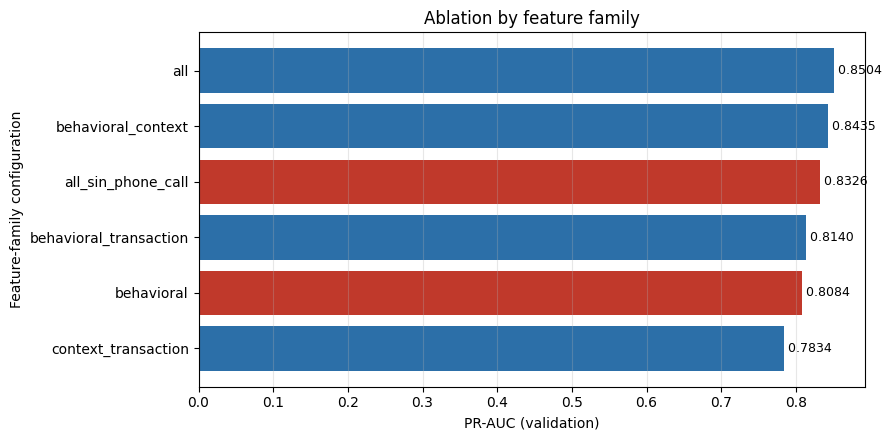

In [6]:
import matplotlib.pyplot as plt

orden = abl.sort_values("pr_auc")
fig, ax = plt.subplots(figsize=(9, 4.5))
colores = ["#c0392b" if c in ("behavioral", "all_sin_phone_call")
           else "#2c6fa8" for c in orden.configuracion]
ax.barh(orden.configuracion, orden.pr_auc, color=colores)
ax.set_xlabel("PR-AUC (validation)")
ax.set_ylabel("Feature-family configuration")
ax.set_title("Ablation by feature family")
for i, (c, v) in enumerate(zip(orden.configuracion, orden.pr_auc)):
    ax.text(v, i, " %.4f" % v, va="center", fontsize=9)
ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()